# World Heritage Project Check-in with Supervised Learning

Initial research question: Can we use the World Heritage category and justification text to predict the OUV criteria? After consulting the project with Prof Wang and EDA exploration, final research question is revised to **Can we use the World Heritage description and justification texts to predict their category (Cultural/Natural)?**

In this jupyter notebook, I will present project results from the following aspects and orders:

- EDA

- Tree-based Model: Random Forest

- Linear Model: Logistic Regression



# EDA

## Data overview

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [94]:
# Read data from csv file to a pandas dataframe
df_data = pd.read_csv('whc.csv') 

# check the data size and display the top-n data samples
df_data.shape, display(df_data.head())

,Name EN,Name FR,Name ES,Name RU,Name AR,Name ZH,Short Description EN,Short Description FR,Short Description ES,Short Description RU,...,Region,Region Code,Transboundary,Main Image,Images,UUID,ID,Coordinates,Components,Components Count
0,The works of Jože Plečnik in Ljubljana – Human...,Les œuvres de Jože Plečnik à Ljubljana – une c...,Obras de Jože Plečnik en Liubliana – una conce...,Работы Йоже Плечника в Любляне - городской диз...,أعمال جوزيه بليشنك في مدينة ليوبليانا – تصميم ...,卢布尔雅那的约热·普列赤涅克作品——以人为本的城市设计,The works Jože Plečnik carried in Ljubljana be...,"Les œuvres de Jože Plečnik, réalisées à Ljublj...",La obra que Jože Plečnik llevó a cabo en Liubl...,"Работы Йоже Плечника, выполненные в Любляне в ...",...,Europe and North America,EUR,False,https://data.unesco.org/api/explore/v2.1/catal...,https://whc.unesco.org/document/181314/site_16...,0faea55c-17b3-5c43-9ccb-784ef7071aa6,1643,"46.0433333333, 14.5022222222",{name: Promenade along the Embankments and Bri...,7
1,Fossil Hominid Sites of South Africa,Sites des hominidés fossiles d’Afrique du Sud,Sitios de homínidos fósiles de Sudáfrica,"Стеркфонтейн, Сварткранс, Кромдрай и окрестнос...",موقع الهومنيدات (متحجّرات الإنسان البدائي) في ...,斯泰克方丹、 斯瓦特科兰斯、 科罗姆德拉伊和维罗恩斯的化石遗址,"The Taung Skull Fossil Site, part of the exten...",C’est sur ce site que le célèbre crâne fossile...,"Fue en este sitio donde se encontró, en 1924, ...",Таунг-Скал-Фоссил-Сайт – это одно из добавлени...,...,Africa,AFR,False,https://data.unesco.org/api/explore/v2.1/catal...,https://whc.unesco.org/document/113350/site_09...,e381540f-9349-54cf-8998-ef85cc4a5d51,915,"-24.15861, 29.17694","{name: Makapan Valley, ref: 915bis-002, latitu...",3
2,Robben Island,Robben Island,Robben Island,Остров Роббен-Айленд,جزيرة روبن,罗布恩岛,Robben Island was used at various times betwee...,Robben Island a été utilisée à différentes épo...,Robben Island fue utilizada en diferentes époc...,В период XVII-ХХ вв. Роббен-Айленд использовал...,...,Africa,AFR,False,https://data.unesco.org/api/explore/v2.1/catal...,https://whc.unesco.org/document/113362/site_09...,3c4fd4bf-395c-522b-b349-858d91573e3e,916,"-33.8, 18.36666667","{name: Robben Island, ref: 916, latitude: -33....",1
3,The Emergence of Modern Human Behaviour: The P...,L’émergence du comportement humain moderne : l...,La aparición del comportamiento humano moderno...,Возникновение поведения людей современного тип...,ظهور السلوك البشري الحديث: مستوطنات العصر الحد...,现代人的出现：南非更新世人类遗址,This serial property contributes to the unders...,Ce bien en série contribue à la compréhension ...,Este sitio en serie contribuye a la comprensió...,Этот серийный объект позволяет составить предс...,...,Africa,AFR,False,https://data.unesco.org/api/explore/v2.1/catal...,https://whc.unesco.org/document/198607/site_17...,afa30144-9e1f-51c0-bb7c-183041c5ddcb,1723,"-32.3863888889, 18.4525","{name: Sibhudu Cave, ref: 1723-003, latitude: ...",3
4,ǂKhomani Cultural Landscape,Paysage culturel des ǂKhomani,Paisaje cultural de los ǂkhomani,NaN,منظر الخوماني الثقافي,NaN,The ǂKhomani Cultural Landscape is located at ...,Le paysage culturel des ǂKhomani est situé à l...,Este paisaje cultural se sitúa en la frontera ...,NaN,...,Africa,AFR,False,https://data.unesco.org/api/explore/v2.1/catal...,https://whc.unesco.org/document/158113/site_15...,dad9f15c-9151-522b-a4e6-894b5020c161,1545,"-25.6876111111, 20.3745833333","{name: ǂKhomani Cultural Landscape, ref: 1545,...",1


((1248, 37), None)

## Data cleaning

### check duplicate values

In [95]:
df_data = df_data.drop_duplicates(keep="first")
df_data.shape # no duplicates

(1248, 37)

### keep relevant columns before processing

In [96]:
columns_to_keep = ["Name EN", "Short Description EN", "Justification EN", "Criteria", "Category"]

df = df_data[columns_to_keep].copy()

df.shape, display(df.head(10))

,Name EN,Short Description EN,Justification EN,Criteria,Category
0,The works of Jože Plečnik in Ljubljana – Human...,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...,(iv),Cultural
1,Fossil Hominid Sites of South Africa,"The Taung Skull Fossil Site, part of the exten...",Brief synthesis The undulating landscape conta...,(iii),Cultural
2,Robben Island,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...,(iii),Cultural
3,The Emergence of Modern Human Behaviour: The P...,This serial property contributes to the unders...,"Brief synthesis Diepkloof Rock Shelter, Pinnac...",(iii)(iv)(v),Cultural
4,ǂKhomani Cultural Landscape,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...,(v),Cultural
5,Catalan Romanesque Churches of the Vall de Boí,The narrow Vall de Boí is situated in the high...,Brief synthesis The Vall de Boí is located in ...,(ii)(iv),Cultural
6,Cave of Altamira and Paleolithic Cave Art of N...,Seventeen decorated caves of the Paleolithic a...,"Brief synthesis The caves of Altamira, Peña de...",(i)(iii),Cultural
7,Historic Walled Town of Cuenca,Built by the Moors in a defensive position at ...,Brief synthesis Cuenca is a municipality locat...,(ii)(v),Cultural
8,Historic City of Toledo,"Successively a Roman municipium, the capital o...",Brief synthesis Toledo is a city located in ce...,(i)(ii)(iii)(iv),Cultural
9,Garajonay National Park,"Laurel forest covers some 70% of this park, si...",Brief synthesis Not far off the north-west coa...,(vii)(ix),Natural


((1248, 5), None)

### check missing values

In [97]:
null_sum = df.isnull().sum()
null_sum

Name EN                  0
Short Description EN     0
Justification EN        50
Criteria                16
Category                 0
dtype: int64

We can see that although some samples have no Justification text, all sites have at least Short Description, which is viable for text classification.

What we need to consider cleaning is 
(1) filling NaN in justification text with empty string;
(2) removing samples with missiong "Criteria" value.

In [98]:
df['Justification EN'] = df['Justification EN'].fillna('')

In [99]:
# Drop samples that have no "Criteria" values, either NaN or blank
df = df.dropna(subset=["Criteria"])
df = df[df["Criteria"].str.strip() != ""]
df = df.reset_index(drop=True)
df.shape

(1232, 5)

## Data processing

### Categorical Data

In [100]:
# Convert the following columns to categorical data types
cat_col = ["Criteria", "Category"]
df[cat_col] = df[cat_col].astype('category')
df[cat_col]

# According to the dataset, "Category" column needs one hot encoding (if treated as a feature), or binary encoding (if treated as the target) 
# while "Criteria" column needs multi-hot encoding because each sample has multiple criteria.

,Criteria,Category
0,(iv),Cultural
1,(iii),Cultural
2,(iii),Cultural
3,(iii)(iv)(v),Cultural
4,(v),Cultural
...,...,...
1227,(i)(iii),Cultural
1228,(iv)(v),Cultural
1229,(iii)(iv),Cultural
1230,(vii)(ix)(x),Natural


#### Category (initial feature variable)

In [101]:
df["Category"].value_counts()

Category
Cultural    956
Natural     235
Mixed        41
Name: count, dtype: int64

Check the **distribution** of "Category".

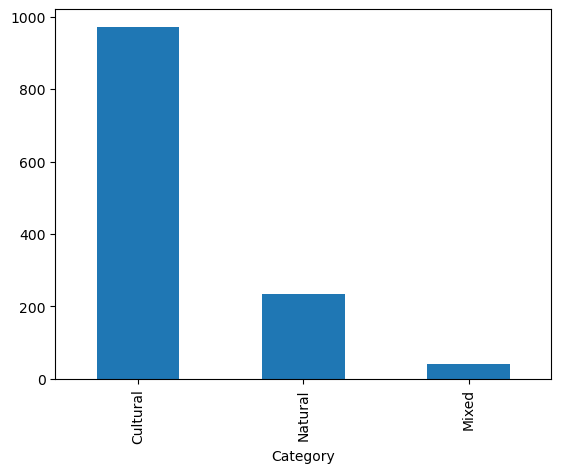

In [102]:
df_data.Category.value_counts().plot(kind='bar')
plt.show()

According to the above observation and Prof Wang's suggestion, I take "Mixed" as the outlier/minority category, and directly **remove** the outlier category.  <br> <br> In addition, noticing the uneven distribution of "Cultural" and "Natural" samples, **undersampling** might be needed at later stage.

In [103]:
# remove outliers
cat_to_remove = ["Mixed"]
df = df[~df["Category"].isin(cat_to_remove)].copy()

In [104]:
df["Category"] = df["Category"].cat.remove_unused_categories()
df["Category"].dtype

CategoricalDtype(categories=['Cultural', 'Natural'], ordered=False, categories_dtype=object)

##### Perform One Hot Encoding (considering "Category" as a feature variable)

In [105]:
from sklearn.preprocessing import OneHotEncoder

In [106]:
# Apply OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(df[["Category"]])

OneHotEncoder(handle_unknown='ignore')

In [107]:
# the learned categories during model fit
ohe.categories_

[array(['Cultural', 'Natural'], dtype=object)]

In [108]:
# encode the "Category" with the learned categories during the fit process
ohe.transform(df[["Category"]]).toarray()[0]

array([1., 0.])

In [109]:
# convert the original "Category" column to the encoded categories
pd.DataFrame(ohe.transform(df[["Category"]]).toarray()).rename(columns={i: catg for i, catg in enumerate(ohe.categories_[0])})

,Cultural,Natural
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
1186,1.0,0.0
1187,1.0,0.0
1188,1.0,0.0
1189,0.0,1.0


#### Criteria (initial target variable)

##### Perform Multi-Hot Encoding

In [110]:
# First, extract and uniform criteria
df["Criteria"] = df["Criteria"].str.findall(r"\((.*?)\)")
df = df.dropna(subset=["Criteria"])
df.shape, display(df.head(10))

,Name EN,Short Description EN,Justification EN,Criteria,Category
0,The works of Jože Plečnik in Ljubljana – Human...,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...,[iv],Cultural
1,Fossil Hominid Sites of South Africa,"The Taung Skull Fossil Site, part of the exten...",Brief synthesis The undulating landscape conta...,[iii],Cultural
2,Robben Island,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...,[iii],Cultural
3,The Emergence of Modern Human Behaviour: The P...,This serial property contributes to the unders...,"Brief synthesis Diepkloof Rock Shelter, Pinnac...","[iii, iv, v]",Cultural
4,ǂKhomani Cultural Landscape,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...,[v],Cultural
5,Catalan Romanesque Churches of the Vall de Boí,The narrow Vall de Boí is situated in the high...,Brief synthesis The Vall de Boí is located in ...,"[ii, iv]",Cultural
6,Cave of Altamira and Paleolithic Cave Art of N...,Seventeen decorated caves of the Paleolithic a...,"Brief synthesis The caves of Altamira, Peña de...","[i, iii]",Cultural
7,Historic Walled Town of Cuenca,Built by the Moors in a defensive position at ...,Brief synthesis Cuenca is a municipality locat...,"[ii, v]",Cultural
8,Historic City of Toledo,"Successively a Roman municipium, the capital o...",Brief synthesis Toledo is a city located in ce...,"[i, ii, iii, iv]",Cultural
9,Garajonay National Park,"Laurel forest covers some 70% of this park, si...",Brief synthesis Not far off the north-west coa...,"[vii, ix]",Natural


((1191, 5), None)

In [111]:
print(type(df["Criteria"].iloc[0]))
print(df["Criteria"].head())

<class 'list'>
0            [iv]
1           [iii]
2           [iii]
3    [iii, iv, v]
4             [v]
Name: Criteria, dtype: object


In [112]:
# Then, perform multi-hot encoding and include results
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
criteria_matrix = mlb.fit_transform(df["Criteria"])

criteria_df = pd.DataFrame(
    criteria_matrix,
    columns=mlb.classes_,
    index=df.index
)

# add results and drop original Criteria column
df = pd.concat([df, criteria_df], axis=1)
df = df.drop(columns=["Criteria"])
display(df.head(10))

,Name EN,Short Description EN,Justification EN,Category,i,ii,iii,iv,ix,v,vii,viii,x
0,The works of Jože Plečnik in Ljubljana – Human...,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...,Cultural,0,0,0,1,0,0,0,0,0
1,Fossil Hominid Sites of South Africa,"The Taung Skull Fossil Site, part of the exten...",Brief synthesis The undulating landscape conta...,Cultural,0,0,1,0,0,0,0,0,0
2,Robben Island,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...,Cultural,0,0,1,0,0,0,0,0,0
3,The Emergence of Modern Human Behaviour: The P...,This serial property contributes to the unders...,"Brief synthesis Diepkloof Rock Shelter, Pinnac...",Cultural,0,0,1,1,0,1,0,0,0
4,ǂKhomani Cultural Landscape,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...,Cultural,0,0,0,0,0,1,0,0,0
5,Catalan Romanesque Churches of the Vall de Boí,The narrow Vall de Boí is situated in the high...,Brief synthesis The Vall de Boí is located in ...,Cultural,0,1,0,1,0,0,0,0,0
6,Cave of Altamira and Paleolithic Cave Art of N...,Seventeen decorated caves of the Paleolithic a...,"Brief synthesis The caves of Altamira, Peña de...",Cultural,1,0,1,0,0,0,0,0,0
7,Historic Walled Town of Cuenca,Built by the Moors in a defensive position at ...,Brief synthesis Cuenca is a municipality locat...,Cultural,0,1,0,0,0,1,0,0,0
8,Historic City of Toledo,"Successively a Roman municipium, the capital o...",Brief synthesis Toledo is a city located in ce...,Cultural,1,1,1,1,0,0,0,0,0
9,Garajonay National Park,"Laurel forest covers some 70% of this park, si...",Brief synthesis Not far off the north-west coa...,Natural,0,0,0,0,1,0,1,0,0


It is noticeable that after processing, Craterion (vi) is missing, which is reasonable, because according to the WHC guidlines, Criterion (vi) is typically not used as the sole criterion for listing, but rather in conjunction with other cultural criteria (i-v) to establish the "Outstanding Universal Value" of a property.

Check the **distribution** of the intended target variables - "criteria_df".

In [113]:
criteria_cols = mlb.classes_.tolist()
criteria_freq = df[criteria_cols].sum().sort_values(ascending=False)
print(criteria_freq)

iv      634
iii     499
ii      476
i       253
v       159
x       148
vii     125
ix      121
viii     90
dtype: int64


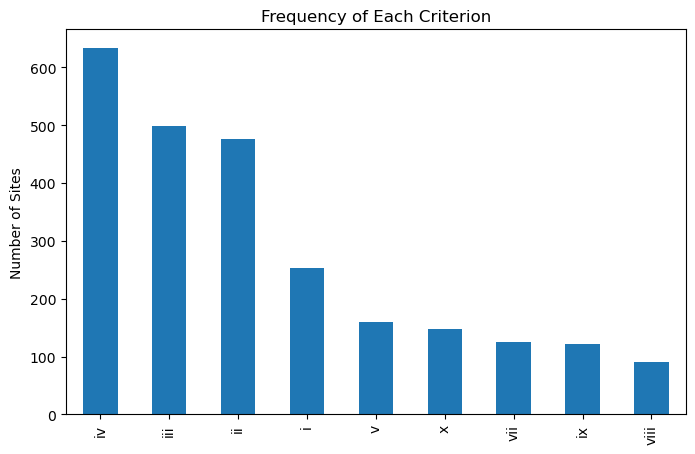

In [114]:
import matplotlib.pyplot as plt
criteria_freq.plot(kind='bar', figsize=(8,5))
plt.title("Frequency of Each Criterion")
plt.ylabel("Number of Sites")
plt.show()

#### Research Question Revised

"Catergory" and "Criteria" have internal and direct relationship:  <br>  <br>
**cultural = ['i','ii','iii','iv','v','vi']**  <br>  <br>
**natural = ['vii','viii','ix','x']**


 According to the above observation and Prof Wang's suggestion for this limited dataset, it is better to reconsider the research question and change to **"Can we use the World Heritage justification text to predict their category?"**

 In this way, it is a text classification where "Description" and "Justification" texts are feature variables and "Category" is the target variable.

In [115]:
# drop criteria
df = df.drop(criteria_df, axis=1)
df.shape, display(df.head(10))

,Name EN,Short Description EN,Justification EN,Category
0,The works of Jože Plečnik in Ljubljana – Human...,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...,Cultural
1,Fossil Hominid Sites of South Africa,"The Taung Skull Fossil Site, part of the exten...",Brief synthesis The undulating landscape conta...,Cultural
2,Robben Island,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...,Cultural
3,The Emergence of Modern Human Behaviour: The P...,This serial property contributes to the unders...,"Brief synthesis Diepkloof Rock Shelter, Pinnac...",Cultural
4,ǂKhomani Cultural Landscape,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...,Cultural
5,Catalan Romanesque Churches of the Vall de Boí,The narrow Vall de Boí is situated in the high...,Brief synthesis The Vall de Boí is located in ...,Cultural
6,Cave of Altamira and Paleolithic Cave Art of N...,Seventeen decorated caves of the Paleolithic a...,"Brief synthesis The caves of Altamira, Peña de...",Cultural
7,Historic Walled Town of Cuenca,Built by the Moors in a defensive position at ...,Brief synthesis Cuenca is a municipality locat...,Cultural
8,Historic City of Toledo,"Successively a Roman municipium, the capital o...",Brief synthesis Toledo is a city located in ce...,Cultural
9,Garajonay National Park,"Laurel forest covers some 70% of this park, si...",Brief synthesis Not far off the north-west coa...,Natural


((1191, 4), None)

#### Category (target variable)

##### Binarize the target variable

In [116]:
df['label'] = df['Category'].map({'Cultural':1,'Natural':0})
display(df.head(10))


,Name EN,Short Description EN,Justification EN,Category,label
0,The works of Jože Plečnik in Ljubljana – Human...,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...,Cultural,1
1,Fossil Hominid Sites of South Africa,"The Taung Skull Fossil Site, part of the exten...",Brief synthesis The undulating landscape conta...,Cultural,1
2,Robben Island,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...,Cultural,1
3,The Emergence of Modern Human Behaviour: The P...,This serial property contributes to the unders...,"Brief synthesis Diepkloof Rock Shelter, Pinnac...",Cultural,1
4,ǂKhomani Cultural Landscape,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...,Cultural,1
5,Catalan Romanesque Churches of the Vall de Boí,The narrow Vall de Boí is situated in the high...,Brief synthesis The Vall de Boí is located in ...,Cultural,1
6,Cave of Altamira and Paleolithic Cave Art of N...,Seventeen decorated caves of the Paleolithic a...,"Brief synthesis The caves of Altamira, Peña de...",Cultural,1
7,Historic Walled Town of Cuenca,Built by the Moors in a defensive position at ...,Brief synthesis Cuenca is a municipality locat...,Cultural,1
8,Historic City of Toledo,"Successively a Roman municipium, the capital o...",Brief synthesis Toledo is a city located in ce...,Cultural,1
9,Garajonay National Park,"Laurel forest covers some 70% of this park, si...",Brief synthesis Not far off the north-west coa...,Natural,0


### Text Data (feature variables)

In [117]:
import nltk
text_col = ["Name EN", "Short Description EN", "Justification EN"]
df[text_col]

,Name EN,Short Description EN,Justification EN
0,The works of Jože Plečnik in Ljubljana – Human...,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...
1,Fossil Hominid Sites of South Africa,"The Taung Skull Fossil Site, part of the exten...",Brief synthesis The undulating landscape conta...
2,Robben Island,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...
3,The Emergence of Modern Human Behaviour: The P...,This serial property contributes to the unders...,"Brief synthesis Diepkloof Rock Shelter, Pinnac..."
4,ǂKhomani Cultural Landscape,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...
...,...,...,...
1227,Great Zimbabwe National Monument,The ruins of Great Zimbabwe – the capital of t...,Brief synthesis Great Zimbabwe National Monume...
1228,Old City of Sana'a,Situated in a mountain valley at an altitude o...,Brief synthesis Situated in a mountain valley ...
1229,Khami Ruins National Monument,"Khami, which developed after the capital of Gr...",Brief synthesis Khami Ruins National Monument ...
1230,"Mana Pools National Park, Sapi and Chewore Saf...","On the banks of the Zambezi, great cliffs over...","Brief synthesis The Mana Pools National Park, ..."


In [118]:
# check the length of Description texts
df['length_d'] = df['Short Description EN'].apply(len) # number of characters
df['length_d'].describe()
# the describe function shows the mean, std, min, max of length of the reviews

count    1191.000000
mean      575.381192
std       247.925197
min       182.000000
25%       381.500000
50%       524.000000
75%       729.000000
max      1943.000000
Name: length_d, dtype: float64

In [119]:
# check the length of Justification texts
df['length_j'] = df['Justification EN'].apply(len) # number of characters
df['length_j'].describe()

count     1191.000000
mean      6656.219983
std       2696.456780
min          0.000000
25%       5087.000000
50%       6666.000000
75%       8240.500000
max      17605.000000
Name: length_j, dtype: float64

In [120]:
display(df.head(10))

,Name EN,Short Description EN,Justification EN,Category,label,length_d,length_j
0,The works of Jože Plečnik in Ljubljana – Human...,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...,Cultural,1,1295,8102
1,Fossil Hominid Sites of South Africa,"The Taung Skull Fossil Site, part of the exten...",Brief synthesis The undulating landscape conta...,Cultural,1,710,6093
2,Robben Island,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...,Cultural,1,346,4646
3,The Emergence of Modern Human Behaviour: The P...,This serial property contributes to the unders...,"Brief synthesis Diepkloof Rock Shelter, Pinnac...",Cultural,1,766,5489
4,ǂKhomani Cultural Landscape,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...,Cultural,1,716,10358
5,Catalan Romanesque Churches of the Vall de Boí,The narrow Vall de Boí is situated in the high...,Brief synthesis The Vall de Boí is located in ...,Cultural,1,303,9394
6,Cave of Altamira and Paleolithic Cave Art of N...,Seventeen decorated caves of the Paleolithic a...,"Brief synthesis The caves of Altamira, Peña de...",Cultural,1,761,11103
7,Historic Walled Town of Cuenca,Built by the Moors in a defensive position at ...,Brief synthesis Cuenca is a municipality locat...,Cultural,1,503,6566
8,Historic City of Toledo,"Successively a Roman municipium, the capital o...",Brief synthesis Toledo is a city located in ce...,Cultural,1,489,8935
9,Garajonay National Park,"Laurel forest covers some 70% of this park, si...",Brief synthesis Not far off the north-west coa...,Natural,0,310,7333


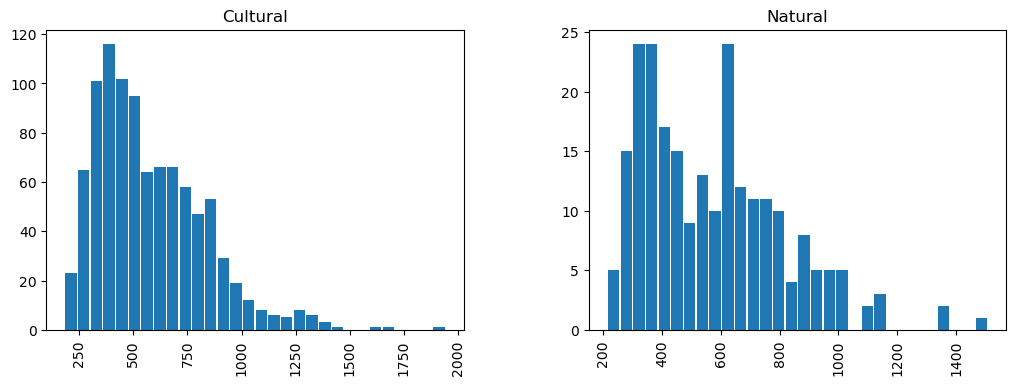

In [121]:
df.hist(column='length_d', by='Category',bins=30, figsize=(12,4),
             rwidth=0.9)
plt.show()

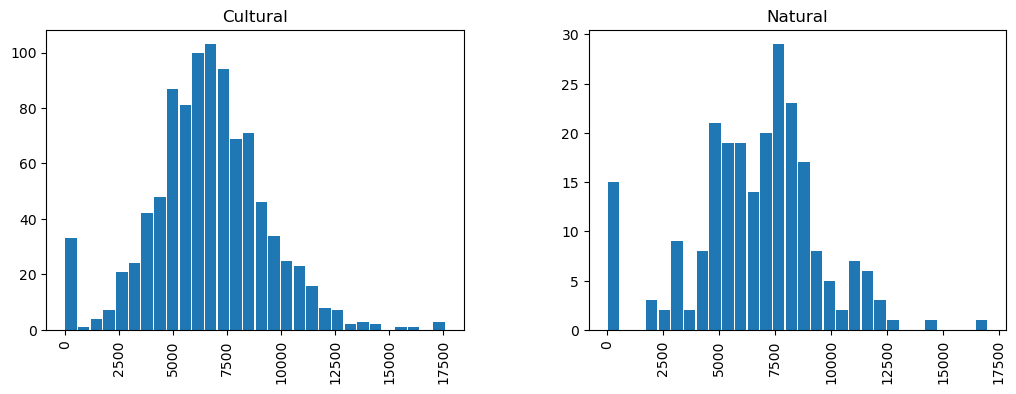

In [122]:
df.hist(column='length_j', by='Category',bins=30, figsize=(12,4),
             rwidth=0.9)
plt.show()

The distribution plot shows that there is no clear difference between Cultural and Natural texts in terms of length.

#### Text Cleaning

Texts for World Heritage Sites are often formal and professional, so the text cleaning is simply: <br>
(1) removing punctuation <br>
(2) expanding contractions into normal words

In [123]:
df["Justification EN"][12]

'Brief synthesis The Royal Monastery of Santa María de Guadalupe is located in the province of Cáceres (Autonomous Community of Extremadura, Spain) at a location of great beauty, overlooking a valley surrounded by high mountains. The town of Guadalupe, built around the Monastery, whose foundation dates back to 1337, offers in its medieval buildings a unique beauty that reflects the traditional architecture in an urban context. It is an exceptional example of an ensemble comprised of widely differing architectural styles, including in particular the 14th- to 15th-century Mudéjar church and cloister. The following architecture from different periods is worth underscoring: the Basilica (main church) or Templo Mayor – with a façade notable for its Mudéjar works, its doors ornamented with finely-worked bronze plaques, the interior nave and two side aisles with fine ornamented vaulting, and many richly decorated tombs and altars. The sacristy built between 1638 and 1647is abundantly decorate

In [124]:
from tqdm import tqdm
import re, string
from bs4 import BeautifulSoup
from nltk.stem import PorterStemmer

In [125]:
def decontracted(phrase):
    """
    Expand contractions into normal words
    """
    # specific
    phrase = re.sub(r"won't", "will not", phrase)
    phrase = re.sub(r"can\'t", "can not", phrase)

    # general
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"\'s", " is", phrase) # prime
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)

    return phrase

def clean_text(df, col):
    """
    Clean the texts
    """
    cleaned_text = []

    for text in tqdm(df[col]):

        # expand contractions
        text = decontracted(text)

        # Removing punctutation, string.punctuation in python consists of !"#$%&\'()*+,-./:;<=>?@[\\]^_{|}~`
        text = text.translate(str.maketrans('', '', string.punctuation))
        # ''.join([char for char in movie_text_data if char not in string.punctuation])

        cleaned_text.append(text)

    return cleaned_text

In [126]:
df['description'] = clean_text(df, "Short Description EN")

df.head()

100%|██████████| 1191/1191 [00:00<00:00, 32627.39it/s]


,Name EN,Short Description EN,Justification EN,Category,label,length_d,length_j,description
0,The works of Jože Plečnik in Ljubljana – Human...,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...,Cultural,1,1295,8102,The works Jože Plečnik carried in Ljubljana be...
1,Fossil Hominid Sites of South Africa,"The Taung Skull Fossil Site, part of the exten...",Brief synthesis The undulating landscape conta...,Cultural,1,710,6093,The Taung Skull Fossil Site part of the extens...
2,Robben Island,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...,Cultural,1,346,4646,Robben Island was used at various times betwee...
3,The Emergence of Modern Human Behaviour: The P...,This serial property contributes to the unders...,"Brief synthesis Diepkloof Rock Shelter, Pinnac...",Cultural,1,766,5489,This serial property contributes to the unders...
4,ǂKhomani Cultural Landscape,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...,Cultural,1,716,10358,The ǂKhomani Cultural Landscape is located at ...


In [127]:
df["justification"] = clean_text(df, "Justification EN")

df.head()

100%|██████████| 1191/1191 [00:00<00:00, 1996.00it/s]


,Name EN,Short Description EN,Justification EN,Category,label,length_d,length_j,description,justification
0,The works of Jože Plečnik in Ljubljana – Human...,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...,Cultural,1,1295,8102,The works Jože Plečnik carried in Ljubljana be...,Brief synthesis The urban design for Ljubljana...
1,Fossil Hominid Sites of South Africa,"The Taung Skull Fossil Site, part of the exten...",Brief synthesis The undulating landscape conta...,Cultural,1,710,6093,The Taung Skull Fossil Site part of the extens...,Brief synthesis The undulating landscape conta...
2,Robben Island,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...,Cultural,1,346,4646,Robben Island was used at various times betwee...,Brief synthesis Robben Island was used at vari...
3,The Emergence of Modern Human Behaviour: The P...,This serial property contributes to the unders...,"Brief synthesis Diepkloof Rock Shelter, Pinnac...",Cultural,1,766,5489,This serial property contributes to the unders...,Brief synthesis Diepkloof Rock Shelter Pinnacl...
4,ǂKhomani Cultural Landscape,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...,Cultural,1,716,10358,The ǂKhomani Cultural Landscape is located at ...,Brief synthesis The ǂKhomani Cultural Landscap...


In [128]:
df["justification"][12]

'Brief synthesis The Royal Monastery of Santa María de Guadalupe is located in the province of Cáceres Autonomous Community of Extremadura Spain at a location of great beauty overlooking a valley surrounded by high mountains The town of Guadalupe built around the Monastery whose foundation dates back to 1337 offers in its medieval buildings a unique beauty that reflects the traditional architecture in an urban context It is an exceptional example of an ensemble comprised of widely differing architectural styles including in particular the 14th to 15thcentury Mudéjar church and cloister The following architecture from different periods is worth underscoring the Basilica main church or Templo Mayor – with a façade notable for its Mudéjar works its doors ornamented with finelyworked bronze plaques the interior nave and two side aisles with fine ornamented vaulting and many richly decorated tombs and altars The sacristy built between 1638 and 1647is abundantly decorated and best known for 

#### Text Data Representation
We have `CountVectorizer`, `TfidfVectorizer`, `Embeddings` these vectorization methods learned through classes and assignments. <br> <br>
In this project, I will use `TfidfVectorizer` to process texts as it is fast, interpretable, works well with small to medium datasets, and gives higher weight to distinctive words.
<br><br> 

In [129]:
# define personalized stopwords for the purpose of pre-eliminating repetitive words in each document such as "Brief sythesis" in justification texts
stopwords= list(set(['br', 'the', 'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've",\
            "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', \
            'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their',\
            'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', \
            'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', \
            'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', \
            'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after',\
            'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further',\
            'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',\
            'most', 'other', 'some', 'such', 'only', 'own', 'same', 'so', 'than', 'too', 'very', \
            's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', \
            've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn',\
            "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',\
            "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", \
            'won', "won't", 'wouldn', "wouldn't", "brief", "synthesis", "year", "years", "ago", "well", "million", "thousand", \
            "also", "many", "century", "centuries", "one", "world", "including", "ha", "i", "ii", "iii", "iv", "v", "vi", "vii", "viii", "ix", "x"]))

In [130]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorizer for Description
vectorizer_desc = TfidfVectorizer(stop_words=stopwords, max_df=0.9, min_df=3, ngram_range=(1,1))
X_desc = vectorizer_desc.fit_transform(df['description'])

# Vectorizer for Justification
vectorizer_just = TfidfVectorizer(stop_words=stopwords, max_df=0.9, min_df=3, ngram_range=(1,1))
X_just = vectorizer_just.fit_transform(df['justification'])


In [131]:
feature_names_desc = vectorizer_desc.get_feature_names_out()
feature_names_just = vectorizer_just.get_feature_names_out()
combined_feature_names = list(feature_names_desc) + list(feature_names_just)

In [132]:
print("X_desc.shape : ",X_desc.shape)
print("X_just.shape : ",X_just.shape)

X_desc.shape :  (1191, 3224)
X_just.shape :  (1191, 11623)


### Finalize the Feature Matrix
- construct the final data matrix from the processed textual features and categorical target variable
- split the data matrix into training and testing with 70:30 ratio to prepare for model training
- shuffle the data at the same time (random permutations of the collections)
- assign a random state of 42 for reproducible output

In [133]:
y = df.label.values
print("y.shape : ",y.shape)

y.shape :  (1191,)


In [134]:
from scipy.sparse import hstack

X = hstack([X_desc, X_just])

In [135]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                 shuffle=True,
                                                 random_state=42)
# check data size after splitting
print("Training data: X : {}, y : {}".format(X_train.shape, y_train.shape))
print("Testing data: X : {}, y : {}".format(X_test.shape, y_test.shape))

Training data: X : (833, 14847), y : (833,)
Testing data: X : (358, 14847), y : (358,)


In [136]:
from collections import Counter

# check data distribution in train and test
print("Training data distribution", Counter(y_train))
print("Testing data distribution", Counter(y_test))

# we can also see from this distribution that under-sampling is needed

Training data distribution Counter({1: 680, 0: 153})
Testing data distribution Counter({1: 276, 0: 82})


An **alternative choice** to track the train and test index (index information needed for **error analysis**)

In [137]:
# Instead of splitting our data itself, split indices into either training rows or testing rows.
train_idx, test_idx = train_test_split(np.arange(df.shape[0]), test_size=0.3,
                                       shuffle=True, random_state=42)

len(train_idx), len(test_idx)
print("Number of training examples:{}".format(len(train_idx)))
print("Number of testing examples:{}".format(len(test_idx)))

Number of training examples:833
Number of testing examples:358


In [138]:
# And then use these indices to split data directly
X_train = X[train_idx]
y_train = y[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("Training data: X_train : {}, y_train : {}".format(X_train.shape, y_train.shape))
print("Testing data: X_test : {}, y_test : {}".format(X_test.shape, y_test.shape))

Training data: X_train : (833, 14847), y_train : (833,)
Testing data: X_test : (358, 14847), y_test : (358,)


#### Under-sampling
- I use `RandomUnderSampler` to balance the data by randomly selecting a subset of data for the targeted classes
- In addition, I apply `RandomUnderSampler` only on training data to make it balanced for training and test data is unchanged to evaluate performance on realistic distribution

In [139]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)
print(sorted(Counter(y_train_res).items()))

[(np.int64(0), 153), (np.int64(1), 153)]


# Tree-based Model

## Random Forest

### Model Training and Testing

In [140]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=42, criterion='entropy', n_estimators=1000)
rf_clf = rf_clf.fit(X_train_res, y_train_res)
rf_clf.score(X_test,y_test)

0.9916201117318436

An **alternative** way to do under-sampling, if using original train data without undersampling, set the hyperparamter: class_weight='balanced'

In [141]:
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42, criterion='entropy', n_estimators=1000)
rf_clf = rf_clf.fit(X_train, y_train)
rf_clf.score(X_test,y_test)

0.9748603351955307

#### Parameter tuning and exploration process 

In [142]:
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42, criterion='entropy', n_estimators=200, max_features= None, max_depth= None, min_samples_leaf=1)
rf_clf.fit(X_train, y_train)
rf_clf.score(X_test,y_test)

0.9832402234636871

In [143]:
rf_clf = RandomForestClassifier(random_state=42, criterion='entropy', n_estimators=200, max_features= None, max_depth= None, min_samples_leaf=1)
rf_clf.fit(X_train_res, y_train_res)
rf_clf.score(X_test,y_test)

0.9720670391061452

In [144]:
rf_clf = RandomForestClassifier(random_state=42, criterion='gini', n_estimators=1000)
rf_clf = rf_clf.fit(X_train_res, y_train_res)
rf_clf.score(X_test,y_test)

0.9860335195530726

In [145]:
best_rf_clf = RandomForestClassifier(random_state=42, criterion='entropy', n_estimators=1000)
best_rf_clf.fit(X_train_res, y_train_res)
best_rf_clf.score(X_test,y_test)

0.9916201117318436

By manually parameter tuning, the accuracy can reach 0.99162

It is noticeable that: <br>

- entropy worked better than Gini for TF-IDF + multi-hot features

- 1000 trees gave the best trade-off between stability and computation

- class weights help handle imbalanced data without undersampling

### Interpret the model performance

##### Visualize one tree from Random Forest

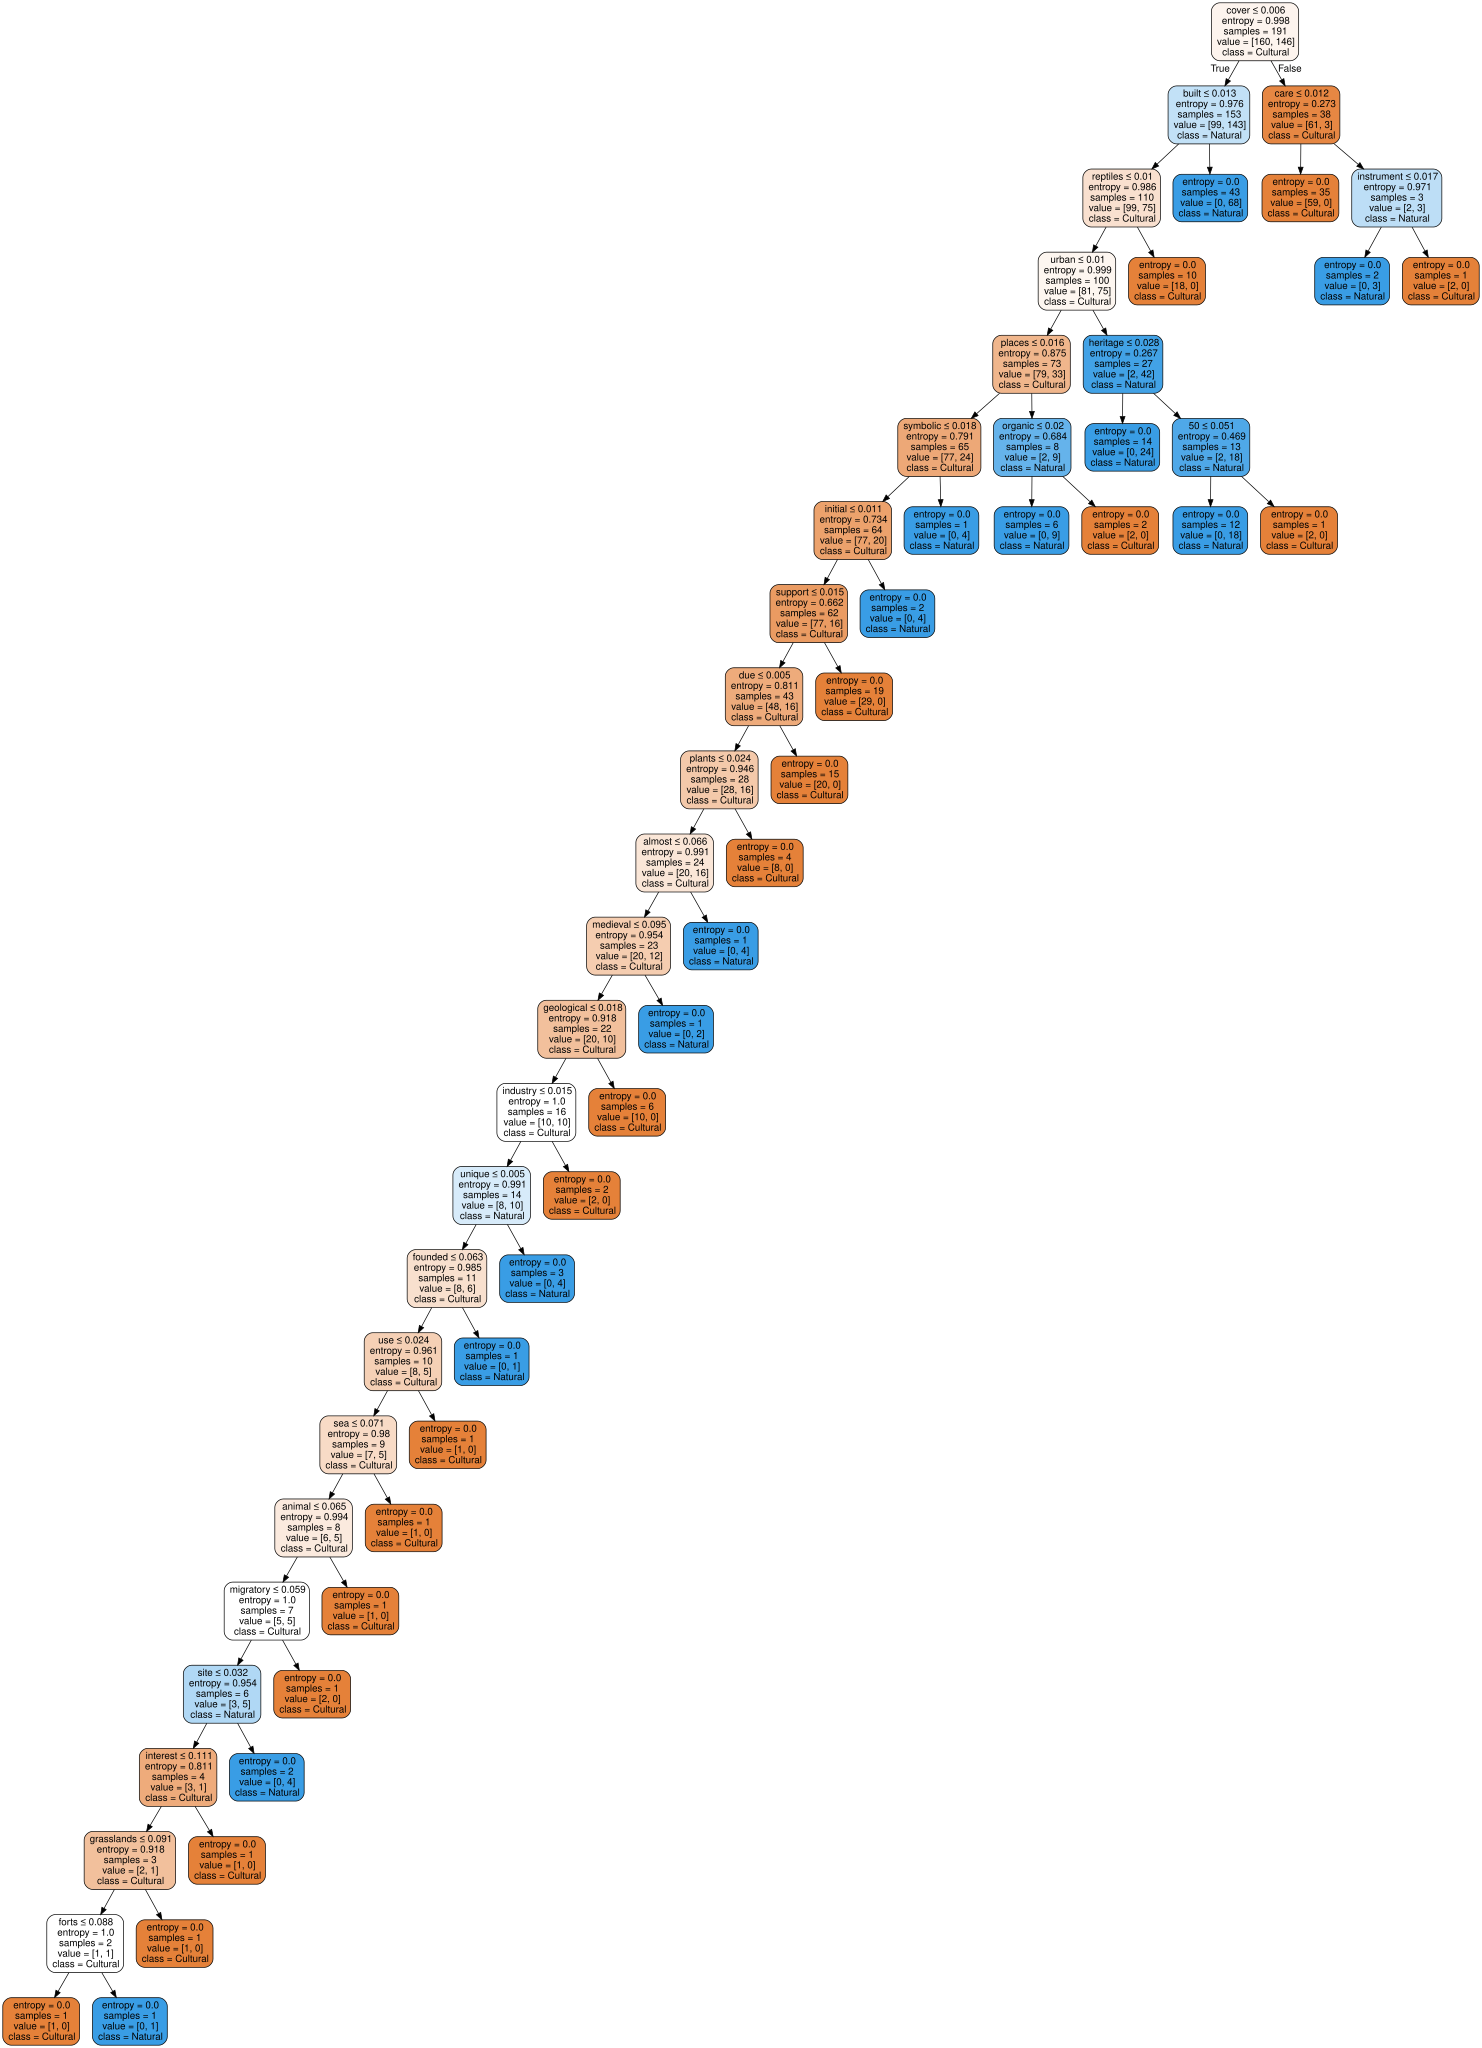

In [146]:
from sklearn import tree
import graphviz

single_tree = best_rf_clf.estimators_[0]

dot_data = tree.export_graphviz(single_tree, out_file=None,
                                feature_names=combined_feature_names,
                                class_names=['Cultural','Natural'],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

#### Quantative Evaluation

In [147]:
y_pred_test = best_rf_clf.predict(X_test)
y_predprob_test = best_rf_clf.predict_proba(X_test)
best_rf_clf.score(X_test, y_test)

0.9916201117318436

In [148]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_test))

print(classification_report(y_test, y_pred_test, 
                            target_names=['Natural','Cultural']))


[[ 82   0]
 [  3 273]]
              precision    recall  f1-score   support

     Natural       0.96      1.00      0.98        82
    Cultural       1.00      0.99      0.99       276

    accuracy                           0.99       358
   macro avg       0.98      0.99      0.99       358
weighted avg       0.99      0.99      0.99       358



#### Qualitative Evaluation
While one could visualize random forests, the models tend to have too many trees for a visual analysis to be very informative. However, we can still calculate feature importances.

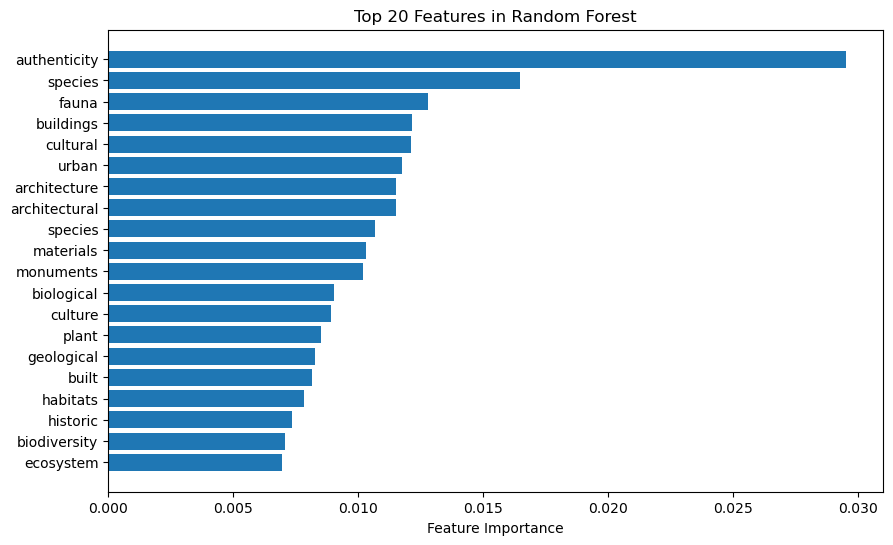

In [149]:
import numpy as np
import matplotlib.pyplot as plt

importances = best_rf_clf.feature_importances_
top_idx = np.argsort(importances)[-20:]
plt.figure(figsize=(10,6))
plt.barh(range(len(top_idx)), importances[top_idx], align='center')
plt.yticks(range(len(top_idx)), [combined_feature_names[i] for i in top_idx])
plt.xlabel('Feature Importance')
plt.title('Top 20 Features in Random Forest')
plt.show()

We can see that Random Forest’s feature_importances_ doesn’t separate by class (Cultural or Natural) — it only tells the overall importance across all classes.

### Error Analysis

#### Where is the problem?

In [150]:
df_test = df.iloc[test_idx]
df_test['pred_label'] = y_pred_test
df_test.head(3)[['Name EN','description', 'justification', 'label','pred_label']]

,Name EN,description,justification,label,pred_label
986,Minoan Palatial Centres,This serial property comprises six archaeologi...,,1,1
257,Group of Monuments at Mahabalipuram,This group of sanctuaries founded by the Palla...,Brief synthesis Mahabalipuram or Mamallapuram ...,1,1
270,Bam and its Cultural Landscape,Bam is situated in a desert environment on the...,Brief synthesis The property of Bam and its Cu...,1,1


In [151]:
errors = df_test[df_test['label'] != df_test['pred_label']]
errors.head()[['Name EN','description', 'justification', 'label','pred_label']] # errors are all from Cultural (1) predicted as Natural (0)

,Name EN,description,justification,label,pred_label
333,Rock-Art Sites of Tadrart Acacus,On the borders of Tassili NAjjer in Algeria al...,,1,0
866,Mir Castle Complex,The construction of this castle began at the e...,,1,0
331,Archaeological Site of Cyrene,A colony of the Greeks of Thera Cyrene was one...,,1,0


In [152]:
df.loc[331]['description']
# we can see some potential natural terminology like "earthquake".

'A colony of the Greeks of Thera Cyrene was one of the principal cities in the Hellenic world It was Romanized and remained a great capital until the earthquake of 365 A thousand years of history is written into its ruins which have been famous since the 18th century'

In [153]:
df.loc[333]['description']
# we can see some potential natural terminology like "rocky".

'On the borders of Tassili NAjjer in Algeria also a World Heritage site this rocky massif has thousands of cave paintings in very different styles dating from 12000 BC to AD 100 They reflect marked changes in the fauna and flora and also the different ways of life of the populations that succeeded one another in this region of the Sahara'

#### Underfitting or Overfitting?

In [ ]:
print("Train accuracy:", best_rf_clf.score(X_train, y_train))
print("Test accuracy:", best_rf_clf.score(X_test, y_test))
# training error is a little higher than testing error, 
# but not that much since the accuracies are all high

Train accuracy: 0.9879951980792316
Test accuracy: 0.9916201117318436


#### Summary
Error analysis shows that all misclassifications occur in Cultural sites. This suggests that there might be lexical bias in TF-IDF features.  However, since we cannot identify matching feature importances to each class, it is hard to provide a conclusion. Moreover, according to the accuracy score, the model has a good performance.



# Linear Model

## Logistic Regression

### Model Training and Testing

In [155]:
from sklearn.linear_model import LogisticRegression

# Create a LogisticRegression classifier
lr_clf = LogisticRegression(penalty='l2')

In [156]:
# Fit the model on resampled training data
lr_clf.fit(X_train_res, y_train_res)

LogisticRegression()

In [157]:
# with the "score" function (accuracy score)
lr_clf.score(X_test, y_test)

0.9972067039106145

An **alternative** way to do under-sampling, if using original train data without undersampling, set the hyperparamter: class_weight='balanced'

In [158]:
lr_clf = LogisticRegression(penalty='l2', class_weight='balanced')

In [159]:
lr_clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [160]:
lr_clf.score(X_test, y_test)

0.9916201117318436

#### Parameter tuning and exploration process 

In [161]:
lr_clf = LogisticRegression(penalty='l2', C=10, class_weight='balanced')
lr_clf.fit(X_train, y_train)
lr_clf.score(X_test, y_test)

0.9972067039106145

In [162]:
best_lr_clf = LogisticRegression(penalty='l2', C=10)
best_lr_clf.fit(X_train_res, y_train_res)
best_lr_clf.score(X_test, y_test)

1.0

In [163]:
lr_clf = LogisticRegression(penalty='l1', C=10, l1_ratio=1, solver='liblinear')
lr_clf.fit(X_train_res, y_train_res)
best_lr_clf.score(X_test, y_test)

1.0

In [164]:
lr_clf = LogisticRegression(penalty='l2', C=10, class_weight='balanced', l1_ratio=1, solver='saga', random_state=42)
lr_clf.fit(X_train, y_train)
lr_clf.score(X_test, y_test)

1.0

By manually parameter tuning, the accuracy can reach 1.0 with multiple models.

It is noticeable that: <br>

- C=10 performs better than C=1 or C=0.1, indicating less focus on model complexity and more emphasis on model fit is better

- class weights help handle imbalanced data without undersampling

- l1 and l2 can all achieve 1.0 accuracy, showing regularization choice is not a issue here.

However, we still need to bear in mind that this dataset is with limited samples, so the result might not be convincing enough when applying this model to predict heritage stie materials outside of official World Heritage Sties.


### Interpret the model performance

#### Quantative Evaluation

In [165]:
y_pred_test = best_lr_clf.predict(X_test)
y_pred_test

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [166]:
best_lr_clf.score(X_test, y_test)

1.0

In [167]:
y_predprob_test = best_lr_clf.predict_proba(X_test)
np.round(y_predprob_test, 3)

array([[0.15 , 0.85 ],
       [0.086, 0.914],
       [0.019, 0.981],
       [0.885, 0.115],
       [0.049, 0.951],
       [0.132, 0.868],
       [0.166, 0.834],
       [0.016, 0.984],
       [0.045, 0.955],
       [0.015, 0.985],
       [0.029, 0.971],
       [0.036, 0.964],
       [0.067, 0.933],
       [0.958, 0.042],
       [0.031, 0.969],
       [0.709, 0.291],
       [0.685, 0.315],
       [0.047, 0.953],
       [0.852, 0.148],
       [0.959, 0.041],
       [0.042, 0.958],
       [0.992, 0.008],
       [0.008, 0.992],
       [0.06 , 0.94 ],
       [0.348, 0.652],
       [0.101, 0.899],
       [0.036, 0.964],
       [0.039, 0.961],
       [0.023, 0.977],
       [0.014, 0.986],
       [0.027, 0.973],
       [0.844, 0.156],
       [0.016, 0.984],
       [0.018, 0.982],
       [0.019, 0.981],
       [0.077, 0.923],
       [0.206, 0.794],
       [0.018, 0.982],
       [0.891, 0.109],
       [0.049, 0.951],
       [0.09 , 0.91 ],
       [0.055, 0.945],
       [0.366, 0.634],
       [0.0

In [168]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_test))

print(classification_report(y_test, y_pred_test, 
                            target_names=['Natural','Cultural']))

[[ 82   0]
 [  0 276]]
              precision    recall  f1-score   support

     Natural       1.00      1.00      1.00        82
    Cultural       1.00      1.00      1.00       276

    accuracy                           1.00       358
   macro avg       1.00      1.00      1.00       358
weighted avg       1.00      1.00      1.00       358



#### Qualitative Evaluation: Top-10 Coefficient Features 

In [169]:
feature_to_coef = {word: float("%.3f" % coef) for word, coef in zip(combined_feature_names, lr_clf.coef_[0])}

In [170]:
# Top features that are predictive of Cultural Heritage
print("Top cultural features:")
sorted(feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:10]

Top cultural features:


[('cultural', 2.482),
 ('archaeological', 1.895),
 ('buildings', 1.695),
 ('sites', 1.613),
 ('landscape', 1.607),
 ('authenticity', 1.593),
 ('city', 1.565),
 ('historic', 1.337),
 ('monuments', 1.309),
 ('urban', 1.252)]

In [171]:
# Top features that are predictive of Natural Heritage
print("Top natural features:")
sorted(feature_to_coef.items(), key=lambda x: x[1], reverse=False)[:10]

Top natural features:


[('species', -4.558),
 ('park', -3.13),
 ('fossil', -2.109),
 ('karst', -2.043),
 ('forest', -2.011),
 ('geological', -1.967),
 ('marine', -1.741),
 ('reserve', -1.713),
 ('endemic', -1.665),
 ('ecological', -1.583)]

Most of the top predictive features make sense:
- words like "buildings, historic, urban" are typically used to express cultural sites; <br>
- words like "species, forest, ecological" are typically used to express natural sites; <br>

**However**, some cultural features like "landscape, authenticity" are not explicity refering to cultural sites. 

Although the accuracy is 1.0, this may indicate the redundant use of such WHC terms in cultural sites' dossiers.

### Error Analysis

In [172]:
df_test = df.iloc[test_idx]
df_test['pred_label'] = y_pred_test
df_test.head(3)[['Name EN','description', 'justification', 'label','pred_label']]

,Name EN,description,justification,label,pred_label
986,Minoan Palatial Centres,This serial property comprises six archaeologi...,,1,1
257,Group of Monuments at Mahabalipuram,This group of sanctuaries founded by the Palla...,Brief synthesis Mahabalipuram or Mamallapuram ...,1,1
270,Bam and its Cultural Landscape,Bam is situated in a desert environment on the...,Brief synthesis The property of Bam and its Cu...,1,1


In [173]:
errors = df_test[df_test['label'] != df_test['pred_label']]
errors.head()[['Name EN','description', 'justification', 'label','pred_label']]

,Name EN,description,justification,label,pred_label


We cannot see any error to analyze potential problems for future dataset by using the best model. So, I will use one model that is not 100% correct to explore the **error analysis** section.

In [174]:
lr_clf = LogisticRegression(penalty='l2', C=10, class_weight='balanced')
lr_clf.fit(X_train, y_train)
lr_clf.score(X_test, y_test)

0.9972067039106145

#### Where is the problem?

In [175]:
y_pred_test = lr_clf.predict(X_test)

In [176]:
df_test = df.iloc[test_idx]
df_test['pred_label'] = y_pred_test
df_test.head(3)[['Name EN','description', 'justification', 'label','pred_label']]

,Name EN,description,justification,label,pred_label
986,Minoan Palatial Centres,This serial property comprises six archaeologi...,,1,1
257,Group of Monuments at Mahabalipuram,This group of sanctuaries founded by the Palla...,Brief synthesis Mahabalipuram or Mamallapuram ...,1,1
270,Bam and its Cultural Landscape,Bam is situated in a desert environment on the...,Brief synthesis The property of Bam and its Cu...,1,1


In [177]:
errors = df_test[df_test['label'] != df_test['pred_label']]
errors.head()[['Name EN','description', 'justification', 'label','pred_label']] # error is from Natural (0) predicted as Cultural (1)

,Name EN,description,justification,label,pred_label
975,Messel Pit Fossil Site,Messel Pit is the richest site in the world fo...,Brief synthesis Messel Pit provides the single...,0,1


In [178]:
df.loc[975]['description']
# we can see some potential natural terminology like "earthquake".

'Messel Pit is the richest site in the world for understanding the living environment of the Eocene between 57 million and 36 million years ago In particular it provides unique information about the early stages of the evolution of mammals and includes exceptionally wellpreserved mammal fossils ranging from fully articulated skeletons to the contents of stomachs of animals of this period'

In [179]:
df.loc[975]['justification']
# we can see some potential natural terminology like "earthquake".

'Brief synthesis Messel Pit provides the single best fossil site which contributes to the understanding of evolution and past environments during the Palaeogene a period which saw the emergence of the first modern mammals The property includes a detailed geological record of middle Eocene age dating from 4748 million years ago It provides unique information about the early stages of the evolution of mammals and is exceptional in the quality of preservation quantity and diversity of fossils of over 1000 species of plants and animals ranging from fully articulated skeletons to feathers skin hair and stomach contents Located in the German Land of Hesse this area of just 42 ha conserves a rich fossiliferous bed of oil shale some 190 m thick Discovered through mining activities the area has now been preserved and has been the subject of important paleontological research which has greatly contributed to our knowledge of evolutionary history Significant scientific discoveries include studies

In [180]:
import textwrap

# We'll use colors for convenience of viewing,
# but your implementations do not need to do this.
RED = '\033[1;31;48m'
BLUE = '\033[1;34;48m'
END = '\033[1;37;0m'

def interpretation(text, vectorizer, wrap_length=250, use_color=True):
    """
    Annotate each word feature with the learned coefficient, and color based on
    coefficient direction
    """
    # Make the annotated string
    analysis = []
    for wd in text.split():
        if wd in vectorizer.vocabulary_:
            wd_id = vectorizer.vocabulary_[wd]
            to_append = wd

            # Red is more negative, blue is more positive
            if use_color and lr_clf.coef_[0][wd_id] < 0:
                to_append = RED + to_append + END
            elif use_color and lr_clf.coef_[0][wd_id] > 0:
                to_append = BLUE + to_append + END

            to_append = to_append+'('+("%.3f" % lr_clf.coef_[0][wd_id])+')'


            analysis.append(to_append)
        else:
            analysis.append(wd)
    result = ' '.join(analysis)

    # Wrap the string for easier viewing
    wrapper = textwrap.TextWrapper(width=wrap_length)
    result = wrapper.fill(text=result)

    print(result)

In [181]:
interpretation(df.loc[975]['description'],vectorizer_desc)

Messel Pit is the richest(-0.250) site(-0.611) in the world for understanding(-0.151) the living(0.419) environment(0.120) of the Eocene between
57(-0.063) million and 36(-0.220) million years ago In particular(0.048) it provides(-0.393) unique(-0.138) information(-0.218) about
the early(0.905) stages(-0.327) of the evolution(-0.181) of mammals(-0.603) and includes(-0.172) exceptionally(-0.339)
wellpreserved(0.253) mammal(-0.651) fossils(-1.375) ranging(-0.068) from fully(0.047) articulated(0.023) skeletons to the contents of
stomachs of animals(-0.287) of this period(0.230)


In [182]:
interpretation(df.loc[975]['justification'],vectorizer_just)

Brief synthesis Messel Pit provides(0.101) the single(0.020) best(-0.928) fossil(-0.012) site(-0.039) which contributes(0.074) to the
understanding(0.008) of evolution(0.012) and past(-0.004) environments(-0.001) during the Palaeogene a period(0.050) which saw(0.041)
the emergence(-0.007) of the first(0.009) modern(0.168) mammals(0.011) The property includes(0.070) a detailed(0.012)
geological(-0.565) record(0.022) of middle(0.044) Eocene age(0.023) dating(0.048) from 4748 million years ago It provides(0.101)
unique(0.089) information(-0.109) about the early(-0.124) stages(0.014) of the evolution(0.012) of mammals(0.011) and is
exceptional(-0.115) in the quality(0.031) of preservation(-0.070) quantity(0.015) and diversity(0.045) of fossils(0.007) of over
1000(0.064) species(0.012) of plants(-0.005) and animals(0.311) ranging(0.072) from fully(0.117) articulated(0.074)
skeletons(0.024) to feathers(0.200) skin(0.036) hair(-0.014) and stomach contents(0.160) Located in the German Land of 

#### Underfitting or Overfitting?

In [183]:
print("Train accuracy:", best_lr_clf.score(X_train_res, y_train_res))
print("Test accuracy:", best_lr_clf.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 1.0


In [ ]:
print("Train accuracy:", lr_clf.score(X_train, y_train))
print("Test accuracy:", lr_clf.score(X_test, y_test))
# training error is a little lower than testing error

Train accuracy: 1.0
Test accuracy: 0.9972067039106145


#### Summary
Error analysis shows that misclassifications occur in one Natural site. According to the feature importance from that site, we can see cultural features are more than natural ones in the description text while justification text has a better natural interpretation. 

Moreover, according to the accuracy score, the model performs generally well with a slightly overfitting problem.



# Summary: Model Comparison

**Logistic Regression** outperforms **Random Forest** in this classification task, likely due to the high-dimensional and sparse nature of TF-IDF features. **Logistic Regression** works very well in this kind of high-dimensional setting because it learns one overall decision boundary using all features together. On the other hand, **Random Forest** makes decisions by splitting on individual features step by step. Since text data has thousands of weak features instead of a few strong ones, tree-based models may struggle to find clean splits. This can make **Random Forest** slightly less stable or less accurate compared to **Logistic Regression**.